In [3]:
!pip install kagglehub pandas

     |████████████████████████████████| 68 kB 6.4 MB/s eta 0:00:011


In [22]:
import kagglehub
import pandas as pd
import os
import re 
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download the dataset
path = kagglehub.dataset_download("girumwondemagegn/semiconductor-companies-of-the-world-by-market-cap")
print("Path to dataset files:", path)

# 2. Find the CSV file inside that directory
files = os.listdir(path)
csv_files = [f for f in files if f.endswith('.csv')]

if len(csv_files) == 0:
    print("No CSV file found in the directory.")
else:
    csv_path = os.path.join(path, csv_files[0])
    print(f"Loading file: {csv_path}")
    
    # Load the base dataset
    df = pd.read_csv(csv_path)
    
    # Print the column names and first few rows to verify it loaded correctly
    print("\n--- Initial Raw Data Sample ---")
    print(df.head())

Path to dataset files: /Users/hannahho/.cache/kagglehub/datasets/girumwondemagegn/semiconductor-companies-of-the-world-by-market-cap/versions/1
Loading file: /Users/hannahho/.cache/kagglehub/datasets/girumwondemagegn/semiconductor-companies-of-the-world-by-market-cap/versions/1/Top_Semiconductors_Companies.csv

--- Initial Raw Data Sample ---
   Rank                                            Company  \
0     1                                 Nvidia Corporation   
1     2                                      Broadcom Inc.   
2     3  Taiwan Semiconductor Manufacturing Company Lim...   
3     4                       Advanced Micro Devices, Inc.   
4     5                                  Intel Corporation   

        Market Cap (USD)         Country                Sector  \
0   1,186,000,000,000.00   United States         US Technology   
1     495,950,000,000.00   United States         US Technology   
2     487,640,000,000.00          Taiwan  Taiwanese Technology   
3     219,720,000,


=== MACRO GEOGRAPHIC SEMICONDUCTOR INTELLIGENCE ===
       Country Total_Market_Cap_USD  Company_Count Average_Valuation_USD Market_Share_Pct
 United States             $2.902 T             66              $48.37 B           69.97%
        Taiwan             $0.718 T            165               $4.38 B           17.32%
         China             $0.161 T             42               $3.83 B            3.88%
   South Korea             $0.075 T              1              $75.21 B            1.81%
         Japan             $0.067 T             32               $2.08 B            1.60%
   Netherlands             $0.056 T              2              $27.86 B            1.34%
       Germany             $0.053 T              3              $17.66 B            1.28%
       Bermuda             $0.050 T              1              $50.20 B            1.21%
   Switzerland             $0.041 T              2              $20.44 B            0.99%
Cayman Islands             $0.007 T            

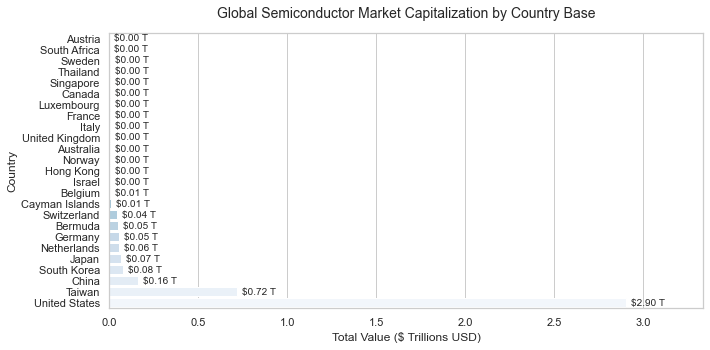

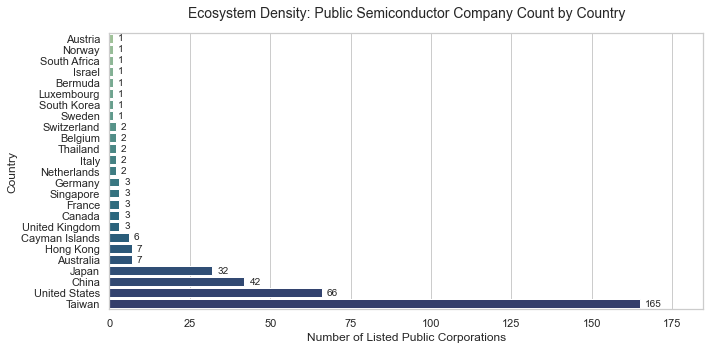

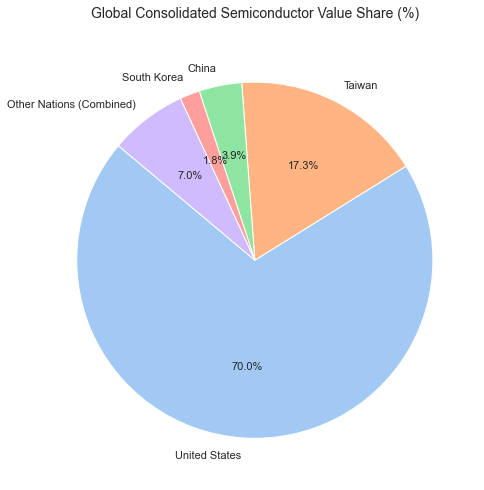


[SUCCESS] Visualizations compiled and saved as high-resolution PNG assets.


In [31]:
# Set clean, publication-ready plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# 1. Download and Load Data Safely
path = kagglehub.dataset_download("girumwondemagegn/semiconductor-companies-of-the-world-by-market-cap")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

# 2. Standardize Strings and Convert Market Cap to Numeric Floats
df.columns = df.columns.str.strip()
df['Market Cap (USD)'] = df['Market Cap (USD)'].astype(str).str.replace(',', '').astype(float)
df['Country'] = df['Country'].str.strip()

# Isolate baseline constants
total_industry_cap = df['Market Cap (USD)'].sum()

# 3. Process Multi-Dimensional Macro Analytics Grouped by Country
country_analysis = df.groupby('Country').agg(
    Total_Market_Cap_USD=('Market Cap (USD)', 'sum'),
    Company_Count=('Company', 'count'),
    Average_Valuation_USD=('Market Cap (USD)', 'mean')
).reset_index()

# Calculate exact geographic market share using LaTeX definition: 
# Market Share = (Country Cap / Total Cap) * 100
country_analysis['Market_Share_Pct'] = (country_analysis['Total_Market_Cap_USD'] / total_industry_cap) * 100

# Sort descending by value to keep all outputs in ranked order
country_analysis = country_analysis.sort_values(by='Total_Market_Cap_USD', ascending=False).reset_index(drop=True)

print("\n=== MACRO GEOGRAPHIC SEMICONDUCTOR INTELLIGENCE ===")
print(country_analysis.to_string(index=False, formatters={
    'Total_Market_Cap_USD': lambda x: f"${x / 1e12:.3f} T",
    'Average_Valuation_USD': lambda x: f"${x / 1e9:.2f} B",
    'Market_Share_Pct': lambda x: f"{x:.2f}%"
}))

# 4. Prepare Data for a Clean Pie Chart (Group small long-tail countries to avoid clutter)
top_n = 4
top_countries = country_analysis.head(top_n).copy()
other_cap = country_analysis.iloc[top_n:]['Total_Market_Cap_USD'].sum()
other_count = country_analysis.iloc[top_n:]['Company_Count'].sum()

other_row = pd.DataFrame([{
    'Country': 'Other Nations (Combined)',
    'Total_Market_Cap_USD': other_cap,
    'Company_Count': other_count,
    'Average_Valuation_USD': other_cap / other_count,
    'Market_Share_Pct': (other_cap / total_industry_cap) * 100
}])
pie_data = pd.concat([top_countries, other_row], ignore_index=True)


# ==========================================
# VISUALIZATION 1: MARKET CAP BY COUNTRY (BAR)
# ==========================================
fig1, ax1 = plt.subplots(figsize=(10, 5))
# Convert to Trillions for readable chart scaling
chart_data_cap = country_analysis.sort_values(by='Total_Market_Cap_USD', ascending=True)
sns.barplot(
    data=chart_data_cap, 
    y='Country', 
    x=chart_data_cap['Total_Market_Cap_USD'] / 1e12, 
    palette='Blues_r',
    ax=ax1
)

# ADD LABELS: Formats values as "$X.XX T" (e.g., $3.15 T)
ax1.bar_label(ax1.containers[0], fmt='$%1.2f T', padding=5, fontsize=10)

ax1.set_title('Global Semiconductor Market Capitalization by Country Base', pad=15)
ax1.set_xlabel('Total Value ($ Trillions USD)')
ax1.set_ylabel('Country')

# Dynamically pad the right side of the x-axis so the text labels don't get cut off
ax1.set_xlim(0, (chart_data_cap['Total_Market_Cap_USD'].max() / 1e12) * 1.15)

plt.tight_layout()
plt.savefig('semiconductor_market_cap_by_country.png', dpi=300)
plt.show()

# ==========================================
# VISUALIZATION 2: COMPANY DEPTH COUNT (BAR)
# ==========================================
fig2, ax2 = plt.subplots(figsize=(10, 5))
chart_data_count = country_analysis.sort_values(by='Company_Count', ascending=True)
sns.barplot(
    data=chart_data_count, 
    y='Country', 
    x='Company_Count', 
    palette='crest',
    ax=ax2
)

# ADD LABELS: Formats values as plain integers (e.g., 42)
ax2.bar_label(ax2.containers[0], fmt='%d', padding=5, fontsize=10)

ax2.set_title('Ecosystem Density: Public Semiconductor Company Count by Country', pad=15)
ax2.set_xlabel('Number of Listed Public Corporations')
ax2.set_ylabel('Country')
# Pad the x-axis slightly for the numbers
ax2.set_xlim(0, chart_data_count['Company_Count'].max() * 1.12)

plt.tight_layout()
plt.savefig('semiconductor_company_count_by_country.png', dpi=300)
plt.show()

# ==========================================
# VISUALIZATION 3: GLOBAL MARKET SHARE (PIE)
# ==========================================
fig3, ax3 = plt.subplots(figsize=(7, 7))
colors = sns.color_palette('pastel')[0:len(pie_data)]

# The pie chart already handles percentages via the autopct parameter!
ax3.pie(
    pie_data['Market_Share_Pct'], 
    labels=pie_data['Country'], 
    autopct='%1.1f%%',   # This explicitly plots the text labels on each slice
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'w', 'linewidth': 1}
)

ax3.set_title('Global Consolidated Semiconductor Value Share (%)', pad=20)
plt.tight_layout()
plt.savefig('semiconductor_global_market_share_pie.png', dpi=300)
plt.show()
print("\n[SUCCESS] Visualizations compiled and saved as high-resolution PNG assets.")

In [18]:
# 1. Clean up column names just in case there are trailing spaces
df.columns = df.columns.str.strip()

# 2. Remove commas and convert the column to actual numbers (floats)
df['Market Cap (USD)'] = df['Market Cap (USD)'].astype(str).str.replace(',', '').astype(float)

# 3. NOW your calculation works perfectly!
total_industry_cap = df['Market Cap (USD)'].sum()
df['Global_Market_Share_Pct'] = (df['Market Cap (USD)'] / total_industry_cap) * 100


print("Total Industry Market Cap Analyzed:", total_industry_cap)
print(f"Total Industry Market Cap Analyzed: ${total_industry_cap / 1e12:.2f} Trillion")

Total Industry Market Cap Analyzed: 4147546902094.0
Total Industry Market Cap Analyzed: $4.15 Trillion


In [32]:
# Calculate what % of the entire global market is controlled by just the Top 5 companies
top_5_global_cap = df.nlargest(5, 'Market Cap (USD)')['Market Cap (USD)'].sum()
top_5_share = (top_5_global_cap / total_industry_cap) * 100

# Calculate what % of the US market cap is just NVIDIA
us_df = df[df['Country'] == 'United States']
nvidia_cap = us_df[us_df['Company'].str.contains('NVIDIA', case=False, na=False)]['Market Cap (USD)'].sum()
nvidia_share_of_us = (nvidia_cap / us_df['Market Cap (USD)'].sum()) * 100

print(f"Top 5 Companies Global Market Share: {top_5_share:.2f}%")
print(f"NVIDIA's Share of the Total US Semiconductor Value: {nvidia_share_of_us:.2f}%")

Top 5 Companies Global Market Share: 62.39%
NVIDIA's Share of the Total US Semiconductor Value: 40.87%
